# AI-Powered Anomaly Detection

In this notebook I will
1. evaluate the model performance.
2. Refine the model to make better predictions.

Before moving further, here are the conclusions that I got after Explorative data analysis.\
What I considered as anomaly are:
* if base_salary deviation from designation average, i.e. ${abs(salary\_deviation)}$ > 1000
* if difference between expected_net_salary and net_salary, i.e. ${abs(salary\_diff)}$ >= 1000

Following conclusions can be made from above analysis and model results :
1. Tolerance based models showed that there are **multiple employees** whose **base salary close to designation average**, but still there were **large no of employees** whose **net salary showed a large positive or negative deviation or difference from expected_net_salary**.
2. Despite having large positive or negative devitation of net_salary from expected_net_salary for many employees, **model still give result of only 1 employee as anomaly** which indicates dataset is the **biased data where anomalies are present in the majority when it should be present as rare**.

In [291]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import IsolationForest

In [292]:
combined_data = pd.read_csv("./data/combined_dataset.csv")

In [293]:
combined_data.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,earned_base,expected_gross_salary,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag,salary_deviation_flag,salary_diff_flag
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,52272.727273,53693.181818,46193.181818,227.272727,2,1,0.046188,1,0,1
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,38181.818182,38579.545455,33329.545455,-2181.818182,1,3,0.096786,1,0,0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,40000.000000,40000.000000,34000.000000,0.000000,0,0,0.056792,1,1,1
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,62500.000000,65000.000000,56750.000000,-3500.000000,2,1,0.055231,1,0,0
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,31363.636364,32045.454545,27545.454545,636.363636,4,7,0.037363,1,1,1


In [294]:
import seaborn as sns

In [295]:
plt.style.use("ggplot")

## Evaluation of the model

In [296]:
features = [
    "base_salary",
    "present_days",
    "overtime_pay_per_hour",
    "LOP_days",
    "department_encoded",
    "designation_encoded",
    "salary_diff",
    'salary_deviation',
    'earned_base',
    "expected_gross_salary",
    "expected_net",
    "updated_net_salary",
    'overtime_hours', 
    'overtime_pay',
]

X = combined_data[features]

In [297]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [298]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.03,  # assume 5% anomalies
    random_state=50
)

model.fit(X_scaled)

IsolationForest(contamination=0.03, random_state=50)

In [299]:
combined_data["anomaly_score"] = model.decision_function(X_scaled)
combined_data["anomaly_flag"] = model.predict(X_scaled)

In [300]:
combined_data.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,earned_base,expected_gross_salary,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag,salary_deviation_flag,salary_diff_flag
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,52272.727273,53693.181818,46193.181818,227.272727,2,1,0.062293,1,0,1
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,38181.818182,38579.545455,33329.545455,-2181.818182,1,3,0.108761,1,0,0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,40000.000000,40000.000000,34000.000000,0.000000,0,0,0.070017,1,1,1
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,62500.000000,65000.000000,56750.000000,-3500.000000,2,1,0.054091,1,0,0
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,31363.636364,32045.454545,27545.454545,636.363636,4,7,0.065757,1,1,1


In [301]:
combined_data["anomaly_flag"].value_counts()

anomaly_flag
 1    19
-1     1
Name: count, dtype: int64

In [302]:
combined_data.sort_values("anomaly_score").head(10)

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,earned_base,expected_gross_salary,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag,salary_deviation_flag,salary_diff_flag
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,102272.727273,108409.090909,94909.090909,-6272.727273,2,11,-0.036361,-1,1,0
9,1010,Pooja,Sales,Sales Manager,65000,2023-10-31,22,19,6,68000,...,65000.000000,67215.909091,57465.909091,3000.000000,4,8,0.027431,1,1,0
12,1013,Arjun,Finance,Senior Accountant,85000,2024-01-31,22,20,5,87500,...,88863.636364,91278.409091,78528.409091,-1363.636364,0,9,0.027707,1,1,0
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,62500.000000,65000.000000,56750.000000,-3500.000000,2,1,0.054091,1,0,0
18,1019,Nikhil,Finance,Accountant,42000,2024-07-31,22,19,0,42000,...,42000.000000,42000.000000,35700.000000,0.000000,0,0,0.054775,1,1,1
6,1007,Vikram,IT,Senior Developer,80000,2023-07-31,22,22,10,85000,...,90909.090909,95454.545455,83454.545455,-5909.090909,2,10,0.061588,1,1,0
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,52272.727273,53693.181818,46193.181818,227.272727,2,1,0.062293,1,0,1
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,31363.636364,32045.454545,27545.454545,636.363636,4,7,0.065757,1,1,1
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,40000.000000,40000.000000,34000.000000,0.000000,0,0,0.070017,1,1,1
15,1016,Isha,IT,Developer,52000,2024-04-30,22,22,7,55500,...,59090.909091,61159.090909,53359.090909,-3590.909091,2,1,0.074215,1,1,0


<Axes: xlabel='updated_net_salary', ylabel='Count'>

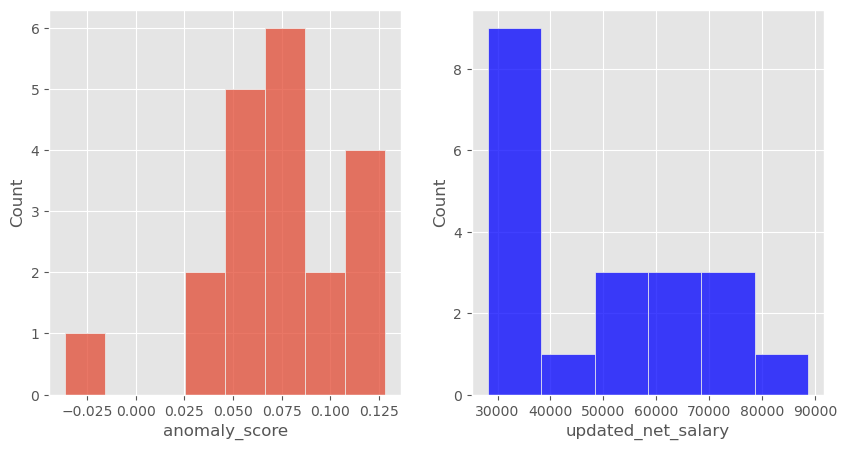

In [303]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(combined_data["anomaly_score"], ax=ax1)
sns.histplot(combined_data["updated_net_salary"], ax=ax2, color="blue")

Hmm, the model is giving me only anomaly but as per the conclusion drwan from EDA, it was concluded that the data was biased that is it has more anomalies as compared to no anomalies. So isolation forest model will not perform better on its own. I need to used **ML model prediction + statistical approach + rule based approach for better predictions**.

## Refining the model for better predictions

For refinement or better predictions we need to use ML model prediction + statistical approach + rule based approach. 
For that I will add few more features that would be help for making better predictions.

In [304]:
combined_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag'],
      dtype='object')

In [305]:
combined_data['salary_dev_pct'] = combined_data['salary_deviation'] / combined_data['average_salary']
combined_data['net_diff_pct'] = combined_data['salary_diff'] / combined_data['expected_net']

In [306]:
combined_data.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag,salary_deviation_flag,salary_diff_flag,salary_dev_pct,net_diff_pct
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,46193.181818,227.272727,2,1,0.062293,1,0,1,-0.044586,0.004920
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,33329.545455,-2181.818182,1,3,0.108761,1,0,0,-0.036697,-0.065462
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,34000.000000,0.000000,0,0,0.070017,1,1,1,-0.024390,0.000000
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,56750.000000,-3500.000000,2,1,0.054091,1,0,0,0.050955,-0.061674
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,27545.454545,636.363636,4,7,0.065757,1,1,1,-0.032258,0.023102


In [307]:
combined_data['rule_violation_score'] = combined_data['salary_deviation_flag'] + combined_data['salary_diff_flag']

In [308]:
combined_data['z_salary_diff'] = (
    combined_data['salary_diff'] - combined_data['salary_diff'].mean()
) / combined_data['salary_diff'].std()

combined_data['z_salary_dev'] = (
    combined_data['salary_deviation'] - combined_data['salary_deviation'].mean()
) / combined_data['salary_deviation'].std()

combined_data['stat_anomaly'] = (
    (combined_data['z_salary_diff'].abs() > 2) |
    (combined_data['z_salary_dev'].abs() > 2)
).astype(int)

In [309]:
features = [
    'salary_deviation',
    'salary_dev_pct',
    'salary_diff',
    'net_diff_pct',
    'rule_violation_score',
    'z_salary_diff',
    'z_salary_dev'
]

X = combined_data[features]

In [310]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [311]:
iso_model = IsolationForest(
    n_estimators=500,
    contamination=0.4,
    random_state=80
)

iso_model.fit(X_scaled)

combined_data['anomaly_flag'] = iso_model.predict(X_scaled)
combined_data['anomaly_score'] = iso_model.decision_function(X_scaled)

In [312]:
combined_data['anomaly_flag'].value_counts()

anomaly_flag
 1    12
-1     8
Name: count, dtype: int64

In [313]:
combined_data['model_anomaly_flag'] = (combined_data['anomaly_flag'] == -1).astype(int)

combined_data['final_anomaly_score'] = (
    combined_data['rule_violation_score']
    + combined_data['stat_anomaly']
    + combined_data['model_anomaly_flag']
)

In [314]:
combined_data['final_anomaly_score'].value_counts()

final_anomaly_score
1    10
2     8
3     2
Name: count, dtype: int64

In [315]:
combined_data['final_anomaly_flag'] = (combined_data['final_anomaly_score'] >= 2).astype(int)

In [316]:
violation_rate = combined_data['final_anomaly_flag'].mean()

if violation_rate > 0.5:
    print("SYSTEMIC PAYROLL ISSUE DETECTED")
else:
    print("Payroll system appears normal")

Payroll system appears normal


In [317]:
print(combined_data['final_anomaly_flag'].value_counts())

final_anomaly_flag
1    10
0    10
Name: count, dtype: int64


After using hybrid approach - **ML model prediction + statistical approach + rule based approach for better predictions** \
The model made better predictions i.e flag 10 as anomalies where it was initially flagged 19 anomalies.

In [318]:
combined_data.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,salary_diff_flag,salary_dev_pct,net_diff_pct,rule_violation_score,z_salary_diff,z_salary_dev,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,1,-0.044586,0.004920,1,0.888704,-2.020726,1,1,3,1
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,0,-0.036697,-0.065462,0,-0.034851,-1.154701,0,1,1,0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,1,-0.024390,0.000000,2,0.801576,-0.866025,0,0,2,1
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,0,0.050955,-0.061674,0,-0.540192,2.309401,1,1,2,1
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,1,-0.032258,0.023102,2,1.045534,-0.866025,0,1,3,1


In [319]:
combined_data.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded', 'anomaly_score',
       'anomaly_flag', 'salary_deviation_flag', 'salary_diff_flag',
       'salary_dev_pct', 'net_diff_pct', 'rule_violation_score',
       'z_salary_diff', 'z_salary_dev', 'stat_anomaly', 'model_anomaly_flag',
       'final_anomaly_score', 'final_anomaly_flag'],
      dtype='object')

In [320]:
combined_data.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,salary_diff_flag,salary_dev_pct,net_diff_pct,rule_violation_score,z_salary_diff,z_salary_dev,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,1,-0.044586,0.004920,1,0.888704,-2.020726,1,1,3,1
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,0,-0.036697,-0.065462,0,-0.034851,-1.154701,0,1,1,0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,1,-0.024390,0.000000,2,0.801576,-0.866025,0,0,2,1
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,0,0.050955,-0.061674,0,-0.540192,2.309401,1,1,2,1
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,1,-0.032258,0.023102,2,1.045534,-0.866025,0,1,3,1


## Final Evaluation and analysis of the model

In [321]:
combined_data['true_anomaly'] = (
    (combined_data['salary_deviation'] > 1000) |
    (combined_data['salary_diff'] >= 1000)
).astype(int)

In [322]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(combined_data['true_anomaly'], combined_data['final_anomaly_flag'])
print(cm)

[[9 8]
 [1 2]]


In [323]:
print(classification_report(
    combined_data['true_anomaly'],
    combined_data['final_anomaly_flag']
))

              precision    recall  f1-score   support

           0       0.90      0.53      0.67        17
           1       0.20      0.67      0.31         3

    accuracy                           0.55        20
   macro avg       0.55      0.60      0.49        20
weighted avg       0.80      0.55      0.61        20



In [324]:
detected = combined_data[combined_data['true_anomaly'] == 1]['final_anomaly_flag'].sum()
total = combined_data['true_anomaly'].sum()

print("Anomaly Detection Rate:", detected / total)

Anomaly Detection Rate: 0.6666666666666666


In [325]:
old_detected = (combined_data['anomaly_flag'] == -1).sum()
new_detected = combined_data['final_anomaly_flag'].sum()

print("Old model anomalies:", old_detected)
print("Refined model anomalies:", new_detected)

Old model anomalies: 8
Refined model anomalies: 10


In [326]:
combined_data['anomaly_score'].describe()

count    20.000000
mean      0.011668
std       0.062636
min      -0.129024
25%      -0.011991
50%       0.007659
75%       0.058876
max       0.099315
Name: anomaly_score, dtype: float64

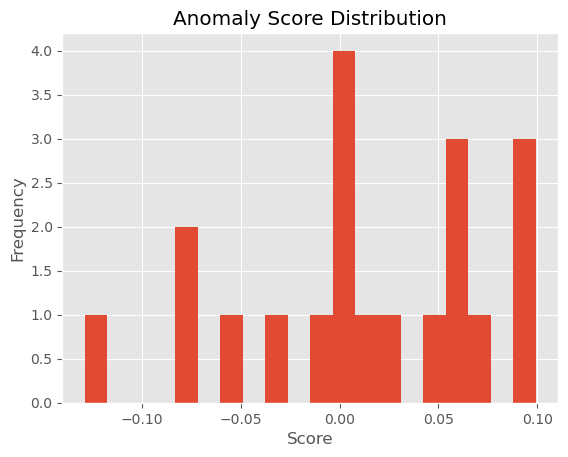

In [327]:
import matplotlib.pyplot as plt

plt.hist(combined_data['anomaly_score'], bins=20)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='salary_deviation', ylabel='salary_diff'>

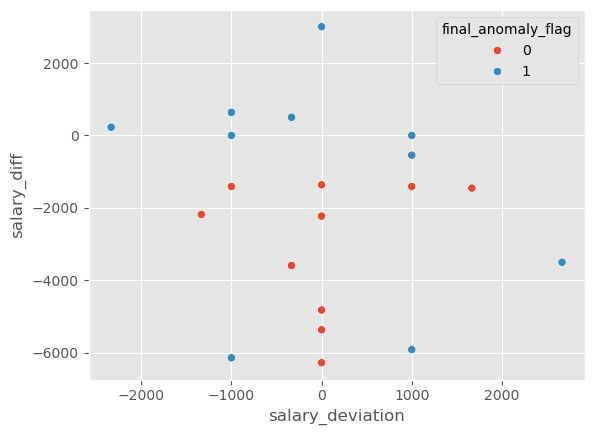

In [328]:
sns.scatterplot(data = combined_data, x = 'salary_deviation', y = 'salary_diff', hue='final_anomaly_flag')

In [329]:
combined_data.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,salary_dev_pct,net_diff_pct,rule_violation_score,z_salary_diff,z_salary_dev,stat_anomaly,model_anomaly_flag,final_anomaly_score,final_anomaly_flag,true_anomaly
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,-0.044586,0.004920,1,0.888704,-2.020726,1,1,3,1,0
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,-0.036697,-0.065462,0,-0.034851,-1.154701,0,1,1,0,0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,-0.024390,0.000000,2,0.801576,-0.866025,0,0,2,1,0
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,0.050955,-0.061674,0,-0.540192,2.309401,1,1,2,1,1
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,-0.032258,0.023102,2,1.045534,-0.866025,0,1,3,1,0


In [330]:
from sklearn.ensemble import IsolationForest

flags = []

for i in range(42):
    model = IsolationForest(
        contamination=0.4,
        random_state=i
    )
    
    f = model.fit_predict(X)
    flags.append((f == -1).astype(int))

flags = np.array(flags)

# Agreement across runs
stability_score = flags.mean(axis=0).mean()

print("Stability Score:", stability_score)

Stability Score: 0.4


In [331]:
group_analysis = combined_data.groupby('department')['final_anomaly_flag'].agg(
    total='count',
    anomalies='sum'
)

group_analysis['anomaly_rate'] = (
    group_analysis['anomalies'] / group_analysis['total']
)
group_analysis.sort_values('anomaly_rate', ascending=False)

,total,anomalies,anomaly_rate
department,,,
IT,6,4,0.666667
Sales,3,2,0.666667
Finance,4,2,0.500000
Marketing,3,1,0.333333
HR,4,1,0.250000


* The maximum no of anomalies are present in **IT department** 
* Anomaly rate is maximum in **IT department**

In [332]:
group_analysis = combined_data.groupby('designation')['final_anomaly_flag'].agg(
    total='count',
    anomalies='sum'
)

group_analysis['anomaly_rate'] = (
    group_analysis['anomalies'] / group_analysis['total']
)
group_analysis.sort_values('anomaly_rate', ascending=False)

,total,anomalies,anomaly_rate
designation,,,
Accountant,2,2,1.000000
Senior Developer,2,2,1.000000
Sales Manager,1,1,1.000000
Developer,3,2,0.666667
Marketing Exec,2,1,0.500000
Sales Exec,2,1,0.500000
HR Executive,3,1,0.333333
Finance Manager,1,0,0.000000
Marketing Manager,1,0,0.000000


* Maximum no of anomalies are present in **Accountant, senior developer, developer**.
* Highest anomaly rate is present in **Accountant, senior developer, sales manager**.

In [333]:
from sklearn.inspection import permutation_importance

# Use model's anomaly scores
scores = iso_model.decision_function(X_scaled)

result = permutation_importance(
    iso_model,
    X_scaled,
    scores,
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_squared_error'
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
4,rule_violation_score,0.008529
6,z_salary_dev,0.006931
0,salary_deviation,0.006331
5,z_salary_diff,0.003635
2,salary_diff,0.003415
3,net_diff_pct,0.003190
1,salary_dev_pct,0.001691


In [334]:
summary = {
    "Total Records": len(combined_data),
    "Total Anomalies": combined_data['final_anomaly_flag'].sum(),
    "Anomaly Rate (%)": combined_data['final_anomaly_flag'].mean()*100,
    "Stability Score": stability_score
}

summary

{'Total Records': 20,
 'Total Anomalies': np.int64(10),
 'Anomaly Rate (%)': np.float64(50.0),
 'Stability Score': np.float64(0.4)}

In [335]:
for k, v in summary.items():
    print(f"{k}: {v}")

Total Records: 20
Total Anomalies: 10
Anomaly Rate (%): 50.0
Stability Score: 0.4


## Conclusions

**Following conclusions can be made:-**
1. The system made better predictions when I used hybrid approach as compared to only model appraoch. 
2. This states that we cant only rely on model appraoch, we need to use hybrid approach. 
3. Hybrid approach model is still moderately unstable (stability score - 0.4). It can be due to few reasons:
    * The dataset is very small and biased.
    * There is no proper separation between the anomalies and no anomalies (as seen through the scatter plot).

The final conclusion is that we need more dataset, proper dataset to ensure better predictions and higher stability.

In [336]:
combined_data.to_csv("./data/refined_data.csv", index=False)